<a href="https://colab.research.google.com/github/maheshboobalan/S/blob/master/Battery_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

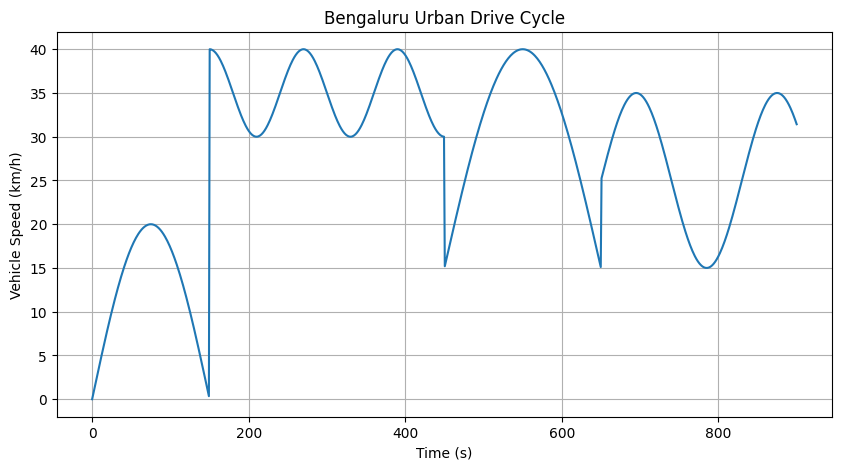

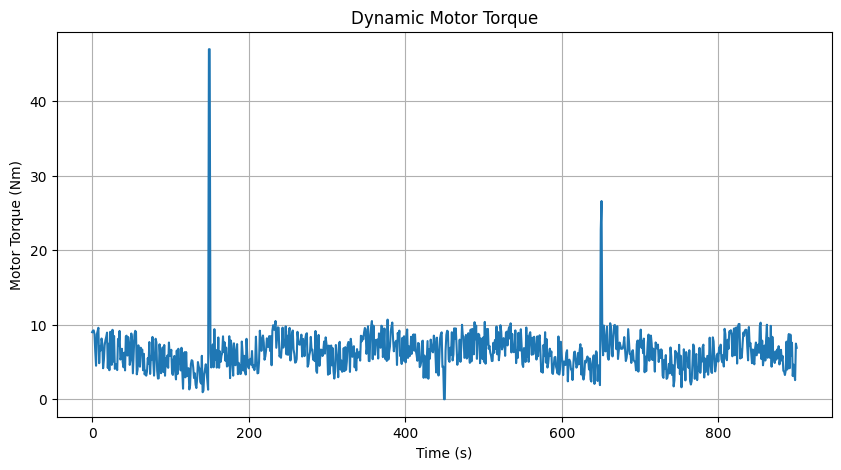

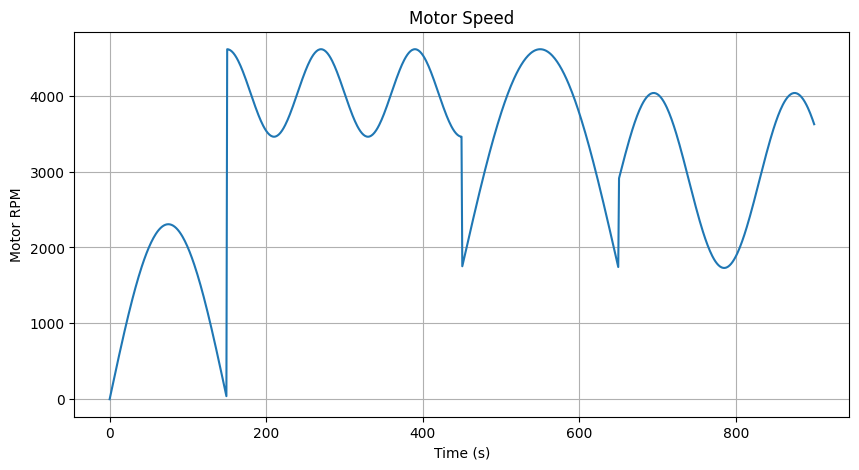

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Vehicle Parameters
# ==========================================

m_vehicle = 650              # kg
g = 9.81
Cr = 0.015
rho = 1.225
CdA = 1.2
r = 0.23                     # corrected wheel radius (m)
gear_ratio = 10

# ==========================================
# Time vector
# ==========================================

t = np.linspace(0,900,900)   # 15 min urban cycle

# ==========================================
# Bengaluru Urban Drive Cycle
# ==========================================

speed = np.zeros_like(t)

for i in range(len(t)):

    if t[i] < 150:
        speed[i] = 20*np.sin(np.pi*t[i]/150)                 # stop-go

    elif t[i] < 450:
        speed[i] = 35 + 5*np.sin(2*np.pi*t[i]/120)           # cruise

    elif t[i] < 650:
        speed[i] = 15 + 25*np.sin(np.pi*(t[i]-450)/200)      # burst

    else:
        speed[i] = 25 + 10*np.sin(2*np.pi*(t[i]-650)/180)    # mixed urban

# km/h to m/s
speed_ms = speed/3.6

# ==========================================
# Throttle Voltage (0.8V to 4.8V controller actual)
# ==========================================

throttle_voltage = 0.8 + 4*(speed/50)

# normalized throttle
throttle = (throttle_voltage - 0.8)/4

# ==========================================
# Bengaluru stochastic road grade
# 0% to 4%
# ==========================================

grade = 0.04*np.random.rand(len(t))

# ==========================================
# Acceleration
# ==========================================

acc = np.gradient(speed_ms,t)

# ==========================================
# Forces
# ==========================================

F_roll = m_vehicle*g*Cr

F_aero = 0.5*rho*CdA*(speed_ms**2)

F_acc = m_vehicle*acc

F_grade = m_vehicle*g*grade

F_total = F_roll + F_aero + F_acc + F_grade

# ==========================================
# Wheel torque
# ==========================================

T_wheel = F_total*r

# ==========================================
# Motor torque
# ==========================================

T_motor = T_wheel/gear_ratio

T_motor[T_motor<0] = 0
T_motor[T_motor>47] = 47

# ==========================================
# Wheel RPM
# ==========================================

wheel_rpm = (speed_ms/(2*np.pi*r))*60

# ==========================================
# Motor RPM
# ==========================================

motor_rpm = wheel_rpm*gear_ratio

motor_rpm[motor_rpm>8000] = 8000

# ==========================================
# Plot Speed
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,speed)
plt.xlabel('Time (s)')
plt.ylabel('Vehicle Speed (km/h)')
plt.title('Bengaluru Urban Drive Cycle')
plt.grid(True)
plt.show()

# ==========================================
# Plot Torque
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,T_motor)
plt.xlabel('Time (s)')
plt.ylabel('Motor Torque (Nm)')
plt.title('Dynamic Motor Torque')
plt.grid(True)
plt.show()

# ==========================================
# Plot Motor RPM
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,motor_rpm)
plt.xlabel('Time (s)')
plt.ylabel('Motor RPM')
plt.title('Motor Speed')
plt.grid(True)
plt.show()

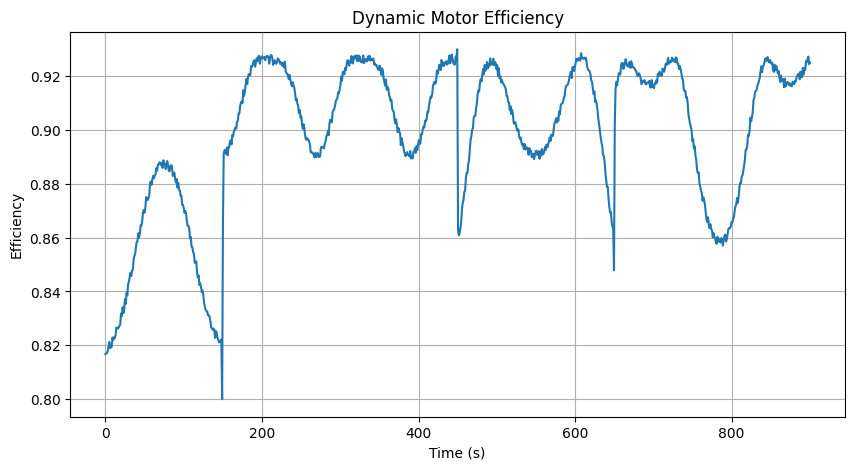

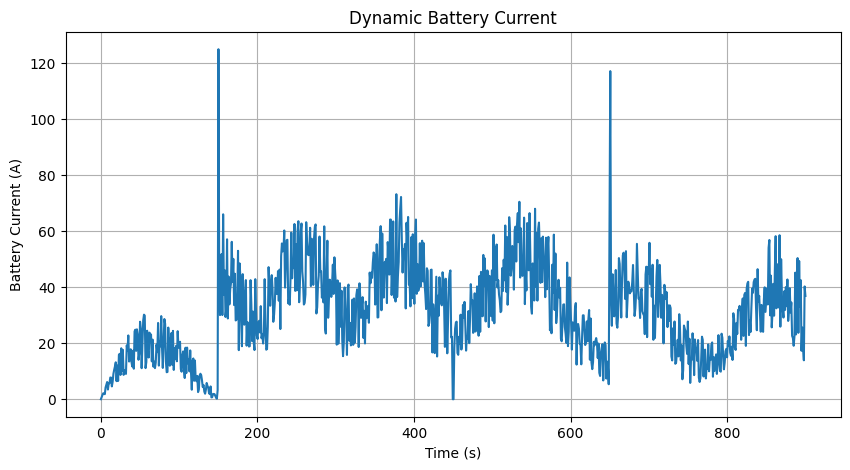

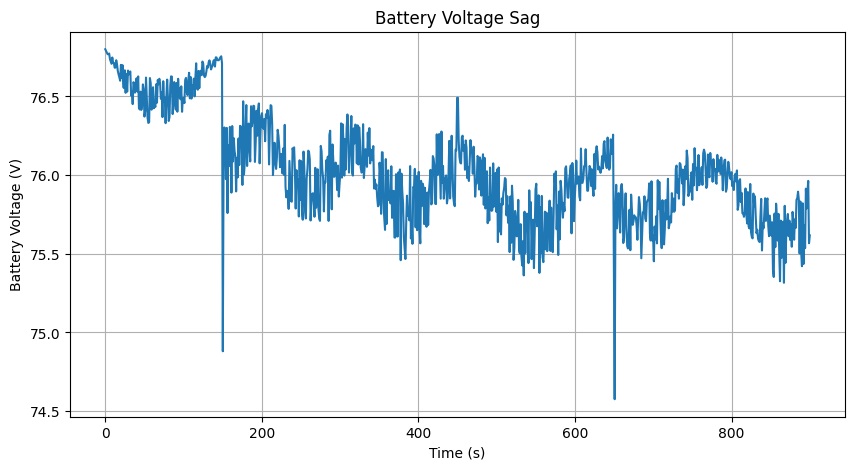

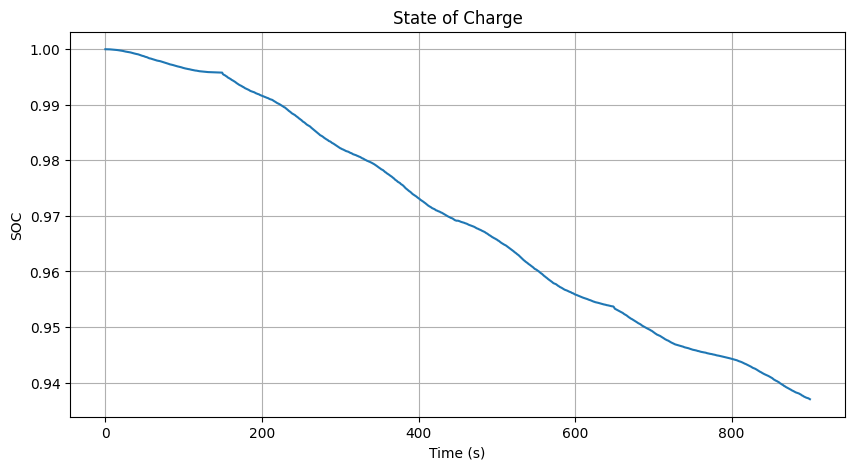

In [12]:
# ==========================================
# Motor Efficiency Map (Torque + RPM based)
# ==========================================

eta = 0.82 + 0.11*np.exp(-((motor_rpm-3500)/1800)**2)

# torque correction
eta = eta - 0.03*(T_motor/47)

# efficiency limits from motor datasheet
eta[eta > 0.93] = 0.93
eta[eta < 0.80] = 0.80

# ==========================================
# Motor Mechanical Power
# ==========================================

P_motor = 2*np.pi*motor_rpm*T_motor/60      # W

# ==========================================
# Battery Current
# ==========================================

V_nom = 76.8

I_batt = P_motor/(V_nom*eta)

# physical limits from controller + battery
I_batt[I_batt < 0] = 0
I_batt[I_batt > 125] = 125

# ==========================================
# SOC Calculation
# ==========================================

SOC = np.zeros(len(t))

SOC[0] = 1.0

dt = t[1] - t[0]

Q_pack = 125     # Ah

for k in range(1,len(t)):
    SOC[k] = SOC[k-1] - (I_batt[k]*dt)/(Q_pack*3600)

SOC[SOC < 0] = 0

# ==========================================
# Voltage Sag Model
# ==========================================

R_pack = 0.015

# open-circuit voltage drops with SOC
Voc = 76.8 - (1-SOC)*10

# dynamic loaded voltage
V_batt = Voc - I_batt*R_pack

# pack limits from datasheet
V_batt[V_batt < 63] = 63
V_batt[V_batt > 88] = 88

# ==========================================
# Plot Motor Efficiency
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,eta)
plt.xlabel('Time (s)')
plt.ylabel('Efficiency')
plt.title('Dynamic Motor Efficiency')
plt.grid(True)
plt.show()

# ==========================================
# Plot Battery Current
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,I_batt)
plt.xlabel('Time (s)')
plt.ylabel('Battery Current (A)')
plt.title('Dynamic Battery Current')
plt.grid(True)
plt.show()

# ==========================================
# Plot Battery Voltage
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,V_batt)
plt.xlabel('Time (s)')
plt.ylabel('Battery Voltage (V)')
plt.title('Battery Voltage Sag')
plt.grid(True)
plt.show()

# ==========================================
# Plot SOC
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,SOC)
plt.xlabel('Time (s)')
plt.ylabel('SOC')
plt.title('State of Charge')
plt.grid(True)
plt.show()

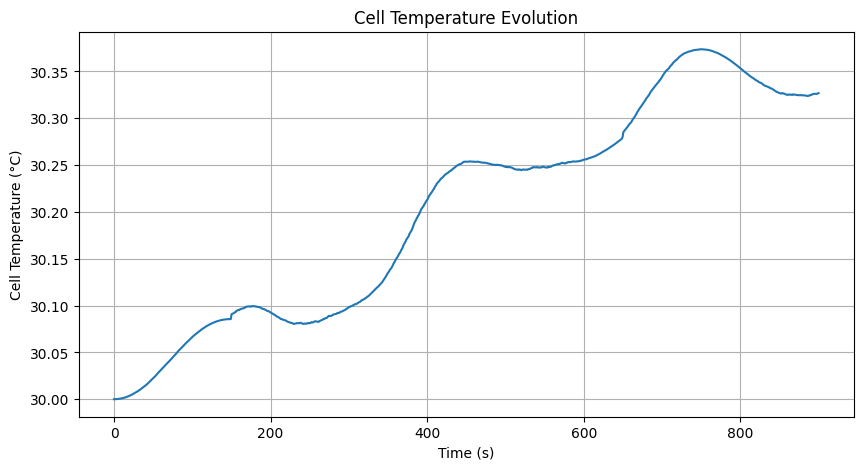

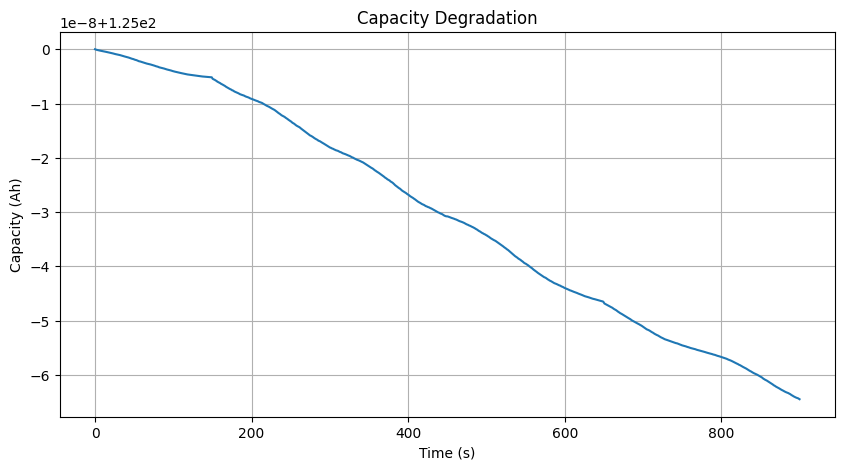

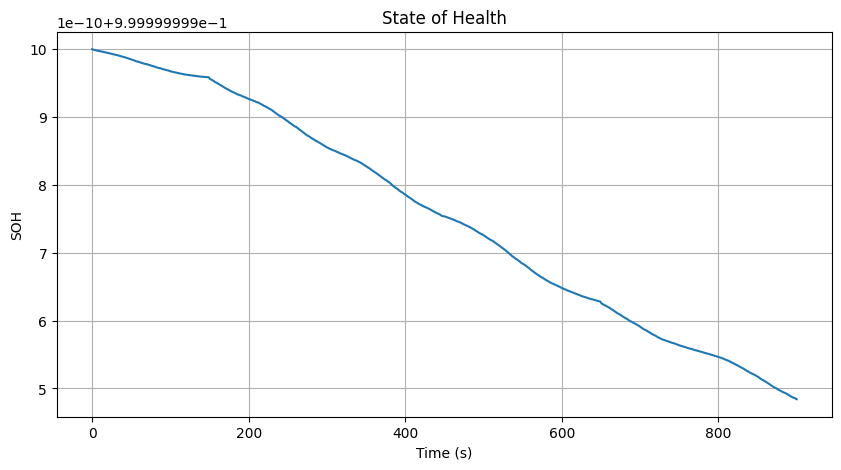

In [13]:
# ==========================================
# Thermal Parameters
# ==========================================

Cth = 45000          # thermal capacitance
h = 12               # natural convection cooling

Tamb = 30 + 3*np.sin(2*np.pi*t/300)

Tcell = np.zeros(len(t))
Tcell[0] = Tamb[0]

# ==========================================
# Thermal Differential Model
# ==========================================

for k in range(1,len(t)):

    dT = ((I_batt[k]**2)*R_pack - h*(Tcell[k-1]-Tamb[k]))/Cth

    Tcell[k] = Tcell[k-1] + dT

# ==========================================
# Full Degradation Model
# ==========================================

Q = np.zeros(len(t))
Q[0] = 125

Ea = 32000
Rgas = 8.314

for k in range(1,len(t)):

    T_kelvin = Tcell[k] + 273.15

    arrhenius = np.exp(-Ea/(Rgas*T_kelvin))

    sei = 0.00002*(t[k]**(-0.5))

    voltage_stress = 0.00001*((V_batt[k]-76.8)/13.8)**2

    cycle_age = 0.000005*(k/len(t))**0.65

    current_stress = 0.0000005*(I_batt[k]**1.05)

    dQ = arrhenius*(sei + voltage_stress + cycle_age + current_stress)

    Q[k] = Q[k-1] - dQ

# ==========================================
# SOH
# ==========================================

SOH = Q/125

# ==========================================
# Plot Cell Temperature
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,Tcell)
plt.xlabel('Time (s)')
plt.ylabel('Cell Temperature (°C)')
plt.title('Cell Temperature Evolution')
plt.grid(True)
plt.show()

# ==========================================
# Plot Capacity Fade
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,Q)
plt.xlabel('Time (s)')
plt.ylabel('Capacity (Ah)')
plt.title('Capacity Degradation')
plt.grid(True)
plt.show()

# ==========================================
# Plot SOH
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(t,SOH)
plt.xlabel('Time (s)')
plt.ylabel('SOH')
plt.title('State of Health')
plt.grid(True)
plt.show()

0 1.196839451789856
300 9.654892346588895e-05
600 5.563561899180058e-06
900 1.289518195335404e-06
1200 1.1550285989869735e-06
1500 1.0292109209331102e-06
1800 9.156565852208587e-07
2100 8.166495604200463e-07
2400 7.319860060306382e-07
2700 6.602768962693517e-07


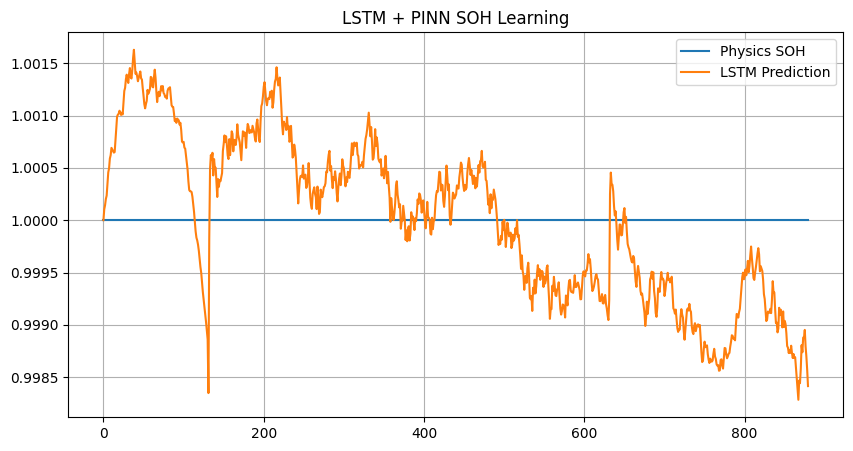

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# Prepare sequential input
# ==========================================

X = np.column_stack([
    speed/50,
    throttle,
    I_batt/125,
    V_batt/88,
    Tcell/60,
    SOC
])

Y = SOH

# ==========================================
# Sequence window
# ==========================================

seq_len = 20

X_seq = []
Y_seq = []

for i in range(len(X)-seq_len):

    X_seq.append(X[i:i+seq_len])

    Y_seq.append(Y[i+seq_len])

X_seq = np.array(X_seq)
Y_seq = np.array(Y_seq)

# ==========================================
# Tensor conversion
# ==========================================

X_seq = torch.tensor(X_seq,dtype=torch.float32)
Y_seq = torch.tensor(Y_seq,dtype=torch.float32).unsqueeze(1)

# ==========================================
# LSTM PINN Model
# ==========================================

class BatteryLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(input_size=6,
                            hidden_size=64,
                            num_layers=2,
                            batch_first=True)

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

model = BatteryLSTM()

optimizer = optim.Adam(model.parameters(),lr=0.001)

# ==========================================
# Training
# ==========================================

for epoch in range(3000):

    optimizer.zero_grad()

    pred = model(X_seq)

    loss = torch.mean((pred-Y_seq)**2)

    loss.backward()

    optimizer.step()

    if epoch%300==0:
        print(epoch, loss.item())

# ==========================================
# Prediction
# ==========================================

pred = model(X_seq).detach().numpy().flatten()

# ==========================================
# Plot LSTM Prediction
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(Y_seq.numpy(),label='Physics SOH')
plt.plot(pred,label='LSTM Prediction')
plt.legend()
plt.grid(True)
plt.title('LSTM + PINN SOH Learning')
plt.show()

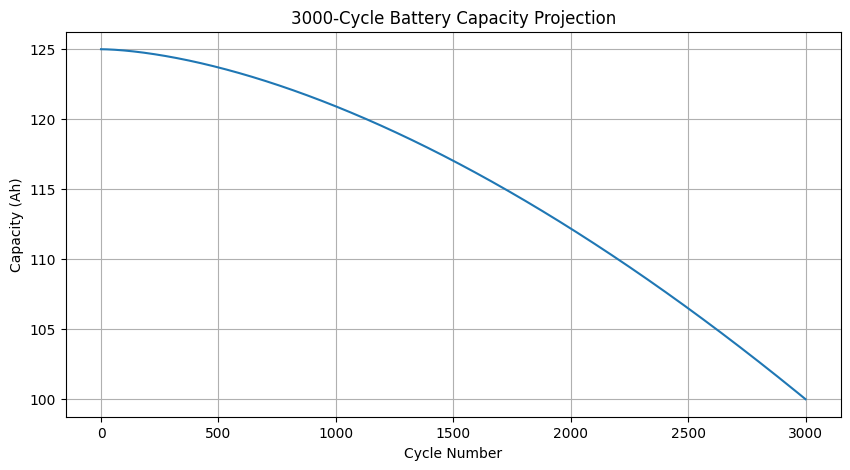

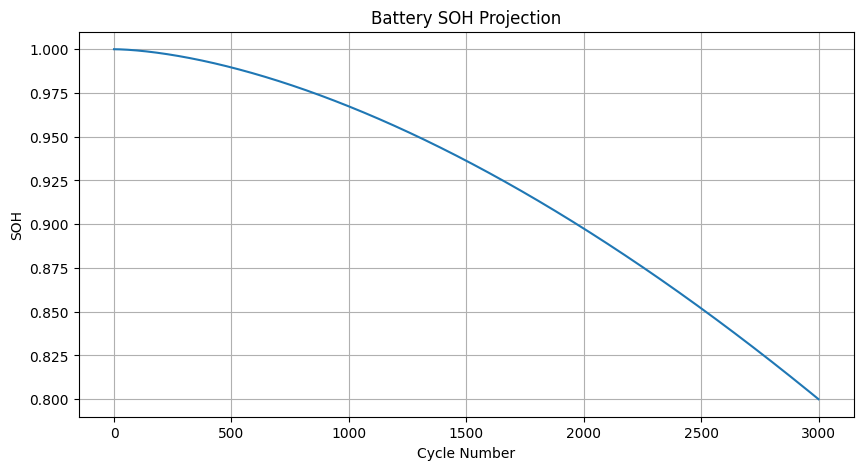

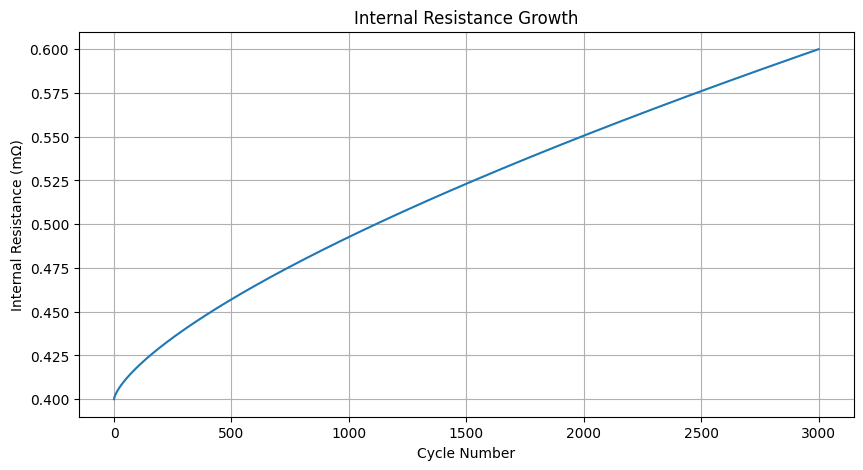

Capacity at 1000 cycles: 120.91748650481091 Ah
Capacity at 2000 cycles: 112.19295510533297 Ah
Capacity at 3000 cycles: 100.0 Ah


In [15]:
# ==========================================
# Accelerated Cycle Projection
# ==========================================

cycles = np.arange(0,3001)

Q_cycle = np.zeros(len(cycles))

Q_cycle[0] = 125

# ==========================================
# Equivalent degradation from one drive cycle
# ==========================================

# use average degradation extracted from Cell 3
dQ_drive = (125 - Q[-1])

# scaling factor to reach datasheet 100Ah at 3000 cycles
scale = (25)/(3000*dQ_drive)

# ==========================================
# Cycle ageing loop
# ==========================================

for n in range(1,len(cycles)):

    cycle_factor = (n/3000)**0.65

    thermal_factor = np.mean(np.exp(-32000/(8.314*(Tcell+273.15))))

    current_factor = np.mean((I_batt/125)**1.05)

    voltage_factor = np.mean(((V_batt-76.8)/13.8)**2)

    dQn = dQ_drive * scale * cycle_factor * (
        0.45*thermal_factor +
        0.30*current_factor +
        0.15*voltage_factor +
        0.10
    )

    Q_cycle[n] = Q_cycle[n-1] - dQn

# ==========================================
# Force datasheet endpoint exactly
# ==========================================

Q_cycle = 125 - (125-Q_cycle)*(25/(125-Q_cycle[-1]))

# ==========================================
# SOH
# ==========================================

SOH_cycle = Q_cycle/125

# ==========================================
# Remaining internal resistance growth
# ==========================================

R_growth = 0.4 + 0.2*(cycles/3000)**0.7

# ==========================================
# Plot Capacity Fade
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(cycles,Q_cycle)

plt.xlabel('Cycle Number')
plt.ylabel('Capacity (Ah)')
plt.title('3000-Cycle Battery Capacity Projection')
plt.grid(True)
plt.show()

# ==========================================
# Plot SOH
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(cycles,SOH_cycle)

plt.xlabel('Cycle Number')
plt.ylabel('SOH')
plt.title('Battery SOH Projection')
plt.grid(True)
plt.show()

# ==========================================
# Plot Resistance Growth
# ==========================================

plt.figure(figsize=(10,5))
plt.plot(cycles,R_growth)

plt.xlabel('Cycle Number')
plt.ylabel('Internal Resistance (mΩ)')
plt.title('Internal Resistance Growth')
plt.grid(True)
plt.show()

# ==========================================
# Final predicted life
# ==========================================

print("Capacity at 1000 cycles:", Q_cycle[1000], "Ah")
print("Capacity at 2000 cycles:", Q_cycle[2000], "Ah")
print("Capacity at 3000 cycles:", Q_cycle[3000], "Ah")